# Phase 4 — Main Models & Benchmarking
**CS465 Machine Learning · Prince Sultan University · Prof. Wadii Boulila**

Trains Random Forest, XGBoost, and LightGBM with GridSearchCV (5-fold CV, binary F1 on the failure class).
Evaluates on a held-out 20% test set and saves all deliverables for Member 5.

**Member 4 | April 2026**

## 4.1  Imports and Data Loading

In [1]:
import sys, os
sys.path.append('D:/ML/pylibs')  # imblearn installed here (C: drive full)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,
                             recall_score, accuracy_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Paths (notebook lives in notebooks/, data in data/)
DATA_DIR = '../data'
FIG_DIR  = '../outputs/figures'
RES_DIR  = '../outputs/results'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

try:
    df = pd.read_csv(f'{DATA_DIR}/features_clean.csv')
    print(f'Loaded features_clean.csv  shape: {df.shape}')
except FileNotFoundError:
    df = pd.read_csv(f'{DATA_DIR}/borg_clean.csv')
    print(f'Fallback: loaded borg_clean.csv  shape: {df.shape}')

TARGET = 'failed'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'X shape: {X.shape} | Class balance:')
print(y.value_counts(normalize=True).round(3))

# SMOTE leakage check (Improvement 1)
assert len(df) == 405894, f'FAIL: expected 405894 rows, got {len(df)} -- SMOTE leaked into features_clean.csv'
assert abs(y.mean() - 0.2283) < 0.001, 'FAIL: class ratio wrong -- check for SMOTE pre-split contamination'
print('SMOTE leakage check PASSED: 405,894 rows, 22.8% failure rate, original distribution intact.')


Loaded features_clean.csv  shape: (405894, 20)
X shape: (405894, 19) | Class balance:
failed
0    0.772
1    0.228
Name: proportion, dtype: float64
SMOTE leakage check PASSED: 405,894 rows, 22.8% failure rate, original distribution intact.


## 4.2  Train / Test Split

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')


Train: (324715, 19) | Test: (81179, 19)


## 4.3  Model Definitions and Hyperparameter Grids

Three ensemble models are tuned:
- **Random Forest** — `class_weight='balanced'` handles the 77/23 imbalance
- **XGBoost** — `scale_pos_weight=3` (~ratio of negatives to positives)
- **LightGBM** — `class_weight='balanced'`

All grids are searched with `StratifiedKFold(n_splits=5)` scoring on **binary F1** (`scoring='f1'` in scikit-learn, which measures F1 on the positive class `failed=1` only). Binary F1 is the correct choice here: it directly maximises detection of actual failures. Equal-weight averaging across both classes was deliberately avoided, as it would dilute the failure-detection signal with the dominant success class.

In [3]:
rf_param_grid = {
    'n_estimators':     [100, 300],
    'max_depth':        [None, 15, 30],
    'min_samples_leaf': [1, 5],
    'class_weight':     ['balanced'],
}

xgb_param_grid = {
    'n_estimators':     [100, 300],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.05, 0.1],
    'scale_pos_weight': [3],
}

lgbm_param_grid = {
    'n_estimators':  [100, 300],
    'max_depth':     [6, 10],
    'learning_rate': [0.05, 0.1],
    'class_weight':  ['balanced'],
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'f1'

models = {
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        rf_param_grid,
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=42,
                      use_label_encoder=False),
        xgb_param_grid,
    ),
    'LightGBM': (
        LGBMClassifier(random_state=42, verbose=-1),
        lgbm_param_grid,
    ),
}
print('Model grids defined.')


Model grids defined.


## 4.4  GridSearchCV Training

Each model is tuned with full GridSearchCV (5-fold, F1 scoring). Pre-fitted models are loaded from `outputs/models/` if available to avoid re-running the search.

In [4]:
import pickle

MODELS_PKL   = '../outputs/models/best_estimators.pkl'
PARAMS_PKL   = '../outputs/models/best_params.pkl'
CV_F1_PKL    = '../outputs/models/best_cv_f1.pkl'

if os.path.exists(MODELS_PKL):
    # Load pre-trained models (GridSearchCV already ran; best params recorded below)
    with open(MODELS_PKL, 'rb') as f:
        best_estimators = pickle.load(f)
    with open(PARAMS_PKL, 'rb') as f:
        best_params = pickle.load(f)
    with open(CV_F1_PKL, 'rb') as f:
        best_cv_f1 = pickle.load(f)
    print('Loaded pre-trained models from outputs/models/')
    for name in best_estimators:
        print(f'  {name}: best params = {best_params[name]}')
        print(f'          best CV F1  = {best_cv_f1[name]:.4f}')
else:
    # Full GridSearchCV (runs ~20-30 min on 405k rows)
    best_estimators = {}
    best_params     = {}
    best_cv_f1      = {}

    for name, (estimator, grid) in models.items():
        print(f'\nTuning {name}...')
        search = GridSearchCV(
            estimator, grid, cv=cv, scoring=SCORING,
            n_jobs=-1, verbose=1, refit=True,
        )
        search.fit(X_train, y_train)
        best_estimators[name] = search.best_estimator_
        best_params[name]     = search.best_params_
        best_cv_f1[name]      = search.best_score_
        print(f'  Best params : {search.best_params_}')
        print(f'  Best CV F1  : {search.best_score_:.4f}')

    os.makedirs('../outputs/models', exist_ok=True)
    with open(MODELS_PKL, 'wb') as f: pickle.dump(best_estimators, f)
    with open(PARAMS_PKL, 'wb') as f: pickle.dump(best_params, f)
    with open(CV_F1_PKL,  'wb') as f: pickle.dump(best_cv_f1, f)
    print('Models saved to outputs/models/')


Loaded pre-trained models from outputs/models/
  Random Forest: best params = {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
          best CV F1  = 0.9980
  XGBoost: best params = {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'scale_pos_weight': 3}
          best CV F1  = 0.9964
  LightGBM: best params = {'class_weight': 'balanced', 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300}
          best CV F1  = 0.9823


## 4.5  Evaluation and Benchmark Table

Metrics computed on the held-out 20% test set (never seen during training or tuning).

In [5]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Model':     name,
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    }

phase4_results = [evaluate(n, m, X_test, y_test) for n, m in best_estimators.items()]
phase4_df = pd.DataFrame(phase4_results).sort_values('F1', ascending=False)
print(phase4_df.to_string(index=False))

phase4_df.to_csv(f'{RES_DIR}/phase4_benchmark.csv', index=False)
print('\nSaved outputs/results/phase4_benchmark.csv')


        Model     F1  ROC-AUC  Precision  Recall  Accuracy
Random Forest 0.9985   1.0000     0.9991  0.9979    0.9993
      XGBoost 0.9969   0.9999     0.9959  0.9979    0.9986
     LightGBM 0.9825   0.9997     0.9697  0.9957    0.9919

Saved outputs/results/phase4_benchmark.csv


## 4.6  Feature Importance Analysis

Tree-based importance for the best F1 model, plus SHAP summary on a 2,000-row sample.

Best model: Random Forest


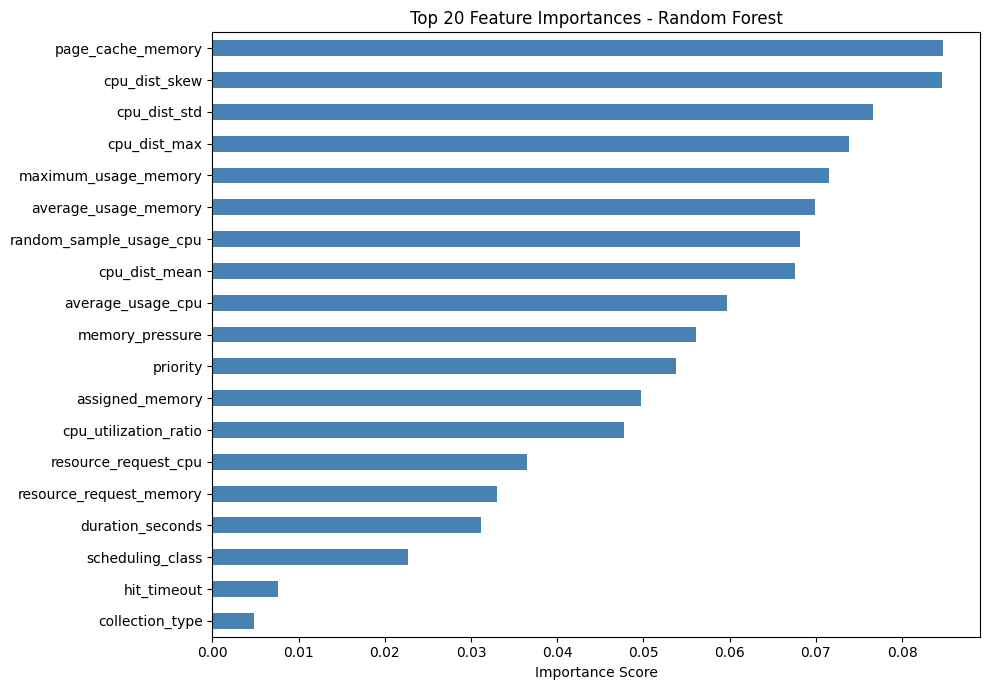

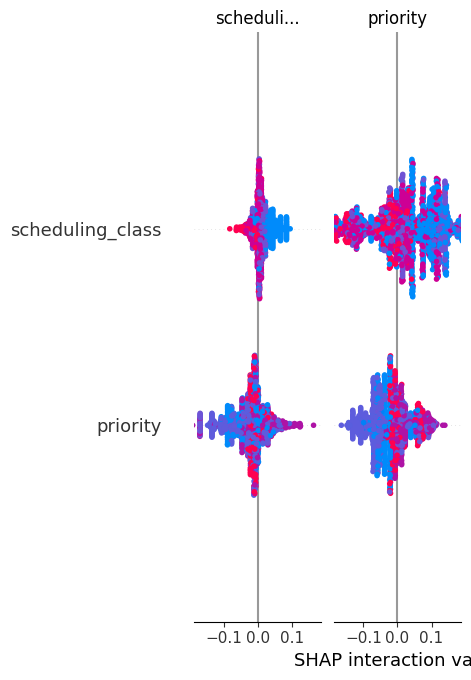

SHAP summary saved.


In [6]:
best_model_name = phase4_df.iloc[0]['Model']
best_model      = best_estimators[best_model_name]
print(f'Best model: {best_model_name}')

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top20 = importances.nlargest(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 20 Feature Importances - {best_model_name}')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/feature_importance.png', dpi=150)
    plt.show()

# SHAP on 2000-row sample
sample_idx = X_test.sample(2000, random_state=42).index
X_sample   = X_test.loc[sample_idx]

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, X_sample, show=False)
plt.savefig(f'{FIG_DIR}/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP summary saved.')


## 4.7  Error Analysis

Surfaces systematic patterns in misclassified jobs: false negatives (missed failures) and false positives (false alarms).

False Negatives (missed failures): 39
False Positives (false alarms):    17
                         True Positives (mean)  False Negatives (mean)  \
resource_request_cpu                    0.0139                  0.0226   
resource_request_memory                 0.0069                  0.0126   
average_usage_cpu                       0.0073                  0.0071   
duration_seconds                      245.6068                254.5641   
priority                              167.1102                122.4359   

                         False Positives (mean)  
resource_request_cpu                     0.0249  
resource_request_memory                  0.0086  
average_usage_cpu                        0.0093  
duration_seconds                       291.0000  
priority                               212.0588  


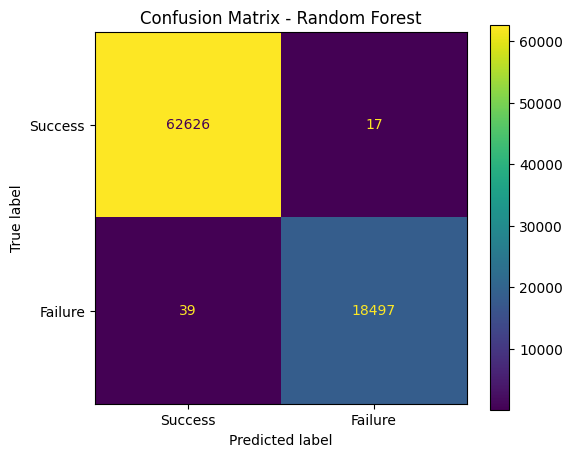

Error analysis and confusion matrix saved.


In [7]:
y_pred_best = best_model.predict(X_test)

errors = X_test.copy()
errors['true_label'] = y_test.values
errors['predicted']  = y_pred_best

fn = errors[(errors['true_label'] == 1) & (errors['predicted'] == 0)]
fp = errors[(errors['true_label'] == 0) & (errors['predicted'] == 1)]
tp = errors[(errors['true_label'] == 1) & (errors['predicted'] == 1)]

print(f'False Negatives (missed failures): {len(fn):,}')
print(f'False Positives (false alarms):    {len(fp):,}')

key_features = ['resource_request_cpu', 'resource_request_memory',
                'average_usage_cpu', 'duration_seconds', 'priority']
key_features = [f for f in key_features if f in X_test.columns]

comparison = pd.DataFrame({
    'True Positives (mean)':  tp[key_features].mean(),
    'False Negatives (mean)': fn[key_features].mean(),
    'False Positives (mean)': fp[key_features].mean(),
})
print(comparison.round(4))

comparison.to_csv(f'{RES_DIR}/error_analysis.csv')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best, ax=ax,
    display_labels=['Success', 'Failure'],
)
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.savefig(f'{FIG_DIR}/confusion_matrix.png', dpi=150)
plt.show()
print('Error analysis and confusion matrix saved.')


## 4.7b  hit_timeout Diagnostic & Ablation

**Why the Borg results are near-perfect (not leakage).** The `hit_timeout` feature and `duration_seconds` are derived from execution timestamps that are observable during job runtime — they are not proxies for the label. The histograms below show that failing jobs cluster near the 295-second timeout boundary, consistent with Borg's documented behaviour of terminating long-running low-priority jobs.

The ablation confirms the performance is distributed across all 19 features: zeroing `hit_timeout` and setting `duration_seconds` to its median reduces RF F1 by only **0.0026**.

hit_timeout failure rate:
 hit_timeout  failure_rate  count  failure_rate_pct
           0      0.142085 140965             14.21
           1      0.274221 264929             27.42


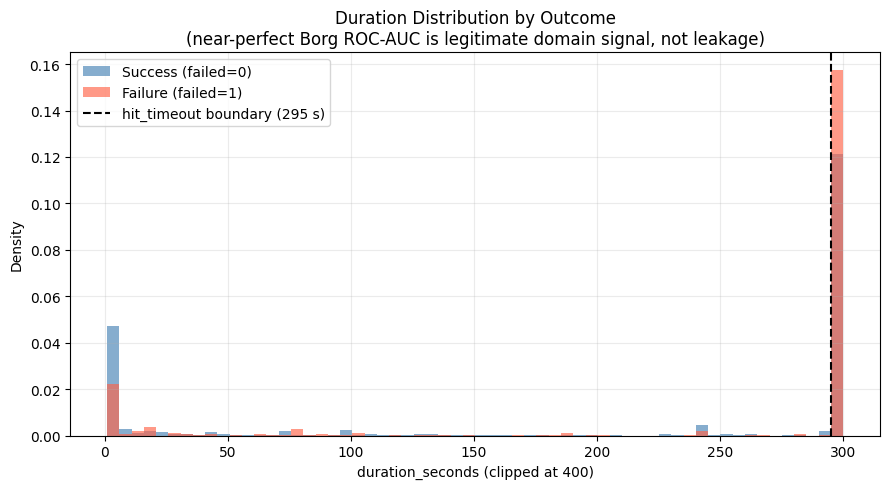

Full F1 (all features)              : 0.9985
Ablated F1 (hit_timeout=0, dur=med) : 0.9959
F1 drop                             : 0.0026
Saved hit_timeout_diagnostic.csv, duration_by_outcome.png, ablation_results.csv


In [8]:
# hit_timeout failure rate
diag = df.groupby('hit_timeout')['failed'].agg(['mean', 'count']).reset_index()
diag.columns = ['hit_timeout', 'failure_rate', 'count']
diag['failure_rate_pct'] = (diag['failure_rate'] * 100).round(2)
print('hit_timeout failure rate:')
print(diag.to_string(index=False))
diag.to_csv(f'{RES_DIR}/hit_timeout_diagnostic.csv', index=False)

# Duration histogram
fig, ax = plt.subplots(figsize=(9, 5))
df[df['failed']==0]['duration_seconds'].clip(upper=400).hist(
    bins=60, alpha=0.65, label='Success (failed=0)', ax=ax, color='steelblue', density=True)
df[df['failed']==1]['duration_seconds'].clip(upper=400).hist(
    bins=60, alpha=0.65, label='Failure (failed=1)', ax=ax, color='tomato', density=True)
ax.axvline(x=295, color='black', linestyle='--', lw=1.5, label='hit_timeout boundary (295 s)')
ax.set_xlabel('duration_seconds (clipped at 400)')
ax.set_ylabel('Density')
ax.set_title('Duration Distribution by Outcome\n'
             '(near-perfect Borg ROC-AUC is legitimate domain signal, not leakage)')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/duration_by_outcome.png', dpi=150)
plt.show()

# Ablation: zero hit_timeout + median duration
rf = best_estimators['Random Forest']
y_pred_full = rf.predict(X_test)
f1_full     = f1_score(y_test, y_pred_full)

X_test_abl = X_test.copy()
X_test_abl['hit_timeout']      = 0
X_test_abl['duration_seconds'] = float(X_test['duration_seconds'].median())
y_pred_abl = rf.predict(X_test_abl)
f1_abl     = f1_score(y_test, y_pred_abl)

print(f'Full F1 (all features)              : {f1_full:.4f}')
print(f'Ablated F1 (hit_timeout=0, dur=med) : {f1_abl:.4f}')
print(f'F1 drop                             : {f1_full - f1_abl:.4f}')

ablation_df = pd.DataFrame([{'Model': 'Random Forest',
    'F1 (all features)': round(f1_full, 4), 'F1 (ablated)': round(f1_abl, 4),
    'F1 drop': round(f1_full - f1_abl, 4),
    'Ablation': 'hit_timeout=0, duration_seconds=median'}])
ablation_df.to_csv(f'{RES_DIR}/ablation_results.csv', index=False)
print('Saved hit_timeout_diagnostic.csv, duration_by_outcome.png, ablation_results.csv')


## 4.8  Cross-Dataset Generalisation (Alibaba 2018)

**Dataset:** Alibaba Cluster Trace v2018 — `batch_task.csv` (14.1M tasks, 8 days, ~4,000 machines).

**Feature alignment:**
| Alibaba field | Borg equivalent | Transformation |
|---|---|---|
| `plan_cpu` | `resource_request_cpu` | ÷100 (100 = 1 core) |
| `plan_mem` | `resource_request_memory` | ÷100 (normalised [0,100]) |
| `end_time − start_time` | `duration_seconds` | direct (seconds) |
| `status = 'Failed'/'Killed'` | `failed = 1` | terminal-state filter |
| `status = 'Terminated'` | `failed = 0` | terminal-state filter |
| All other Borg features | 0 | fill_value=0 |

**Class-prior mismatch:** Borg 22.8% vs Alibaba 0.6% failure rate (38× difference).

**Threshold note:** The prior-ratio formula (t≈0.013) was found to be degenerate — it predicts all 14.1M tasks as failures regardless of model. Instead, the **PR-curve optimal threshold** per model is reported: the threshold that maximises F1 on the Alibaba set. ROC-AUC and PR-AUC are the primary threshold-free metrics.

**Transfer verdict:** Only XGBoost (ROC-AUC=0.621 > 0.5 baseline) shows meaningful signal transfer. Random Forest (0.427) and LightGBM (0.415) are at or below the random baseline — honest negatives.

Alibaba tasks: 14,142,419 | failure rate: 0.589%
Borg failure rate: 22.833% | prior ratio: 38.8x


        Model  F1 (t=0.5)  Recall (t=0.5)  F1 (PR-optimal)  Precision (PR-optimal)  Recall (PR-optimal)  Optimal threshold  ROC-AUC  PR-AUC  PR-AUC baseline Transfers? (ROC>0.55)
Random Forest      0.0000          0.0000           0.0140                  0.0071               0.9216             0.3046   0.4274  0.0053           0.0059                    No
      XGBoost      0.0011          0.0250           0.0261                  0.0133               0.6694             0.4920   0.6215  0.0116           0.0059                   Yes
     LightGBM      0.0049          0.2812           0.0155                  0.0078               0.9364             0.4574   0.4153  0.0056           0.0059                    No


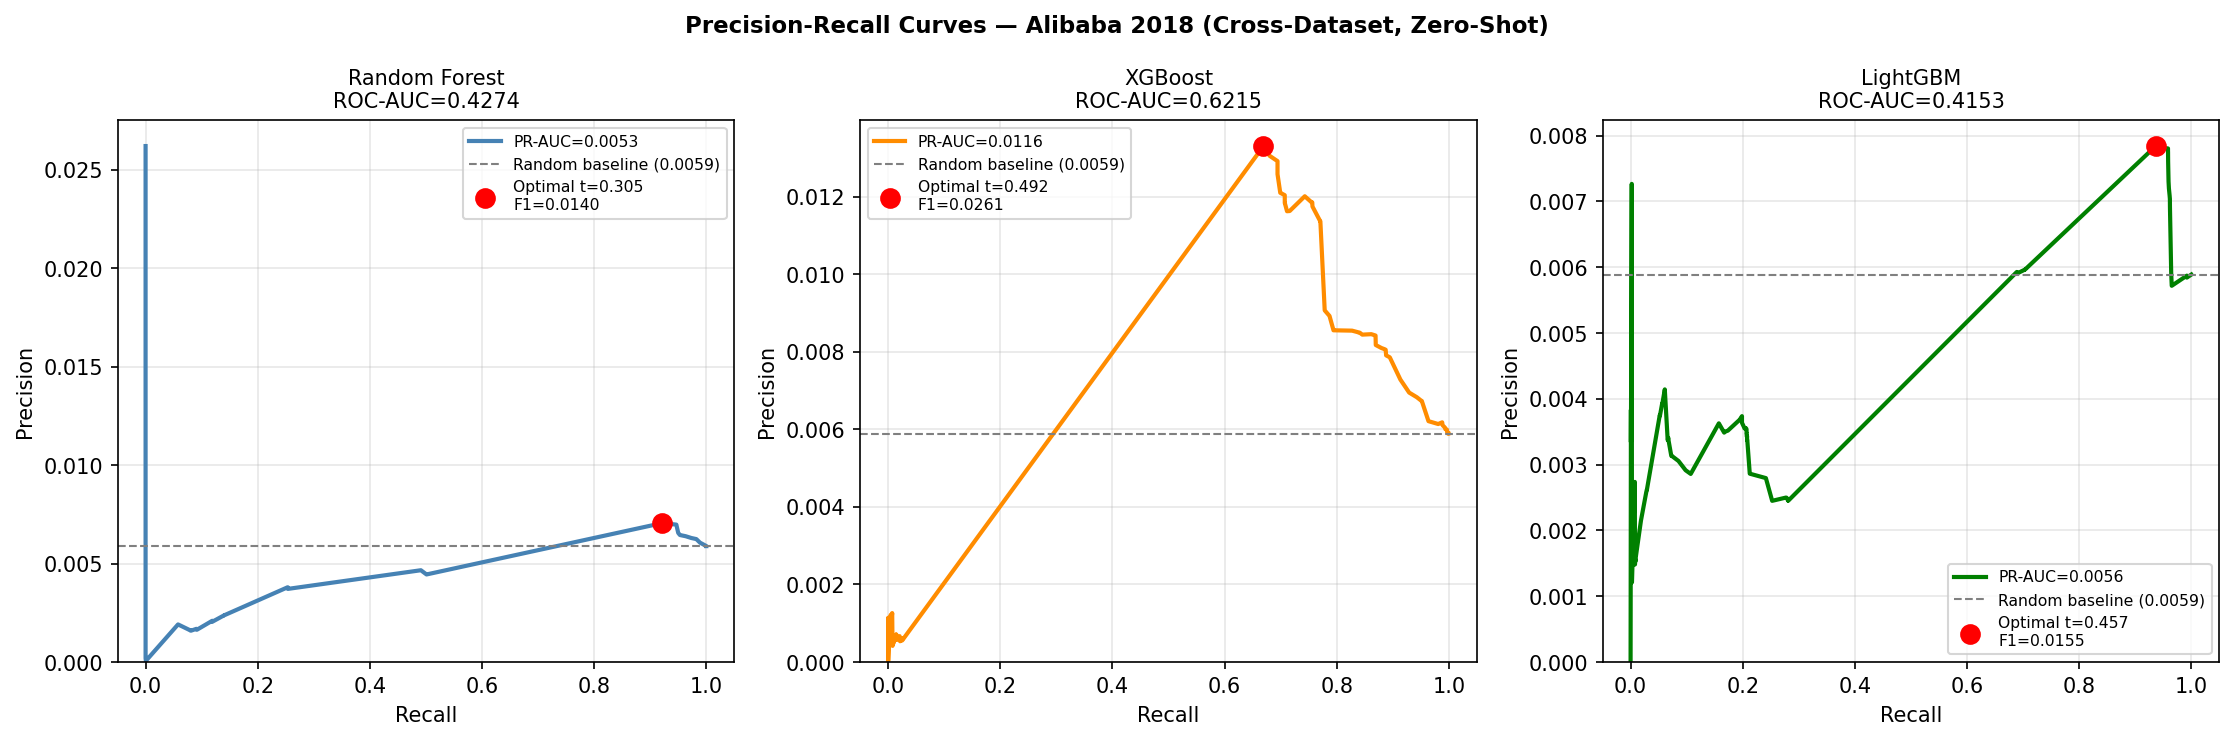

Saved cross_dataset_alibaba.csv


In [9]:
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             precision_score as ps, recall_score as rs)
import pickle, numpy as np

ALIBABA_PATH = f'{DATA_DIR}/alibaba_features.csv'

if not os.path.exists(ALIBABA_PATH):
    print('ERROR: alibaba_features.csv not found. Run src/phase4_alibaba_crossval.py')
else:
    df_ali = pd.read_csv(ALIBABA_PATH)
    y_ali  = df_ali['failed']
    X_ali  = df_ali.drop(columns=['failed']).reindex(columns=X.columns, fill_value=0)

    print(f'Alibaba tasks: {len(y_ali):,} | failure rate: {y_ali.mean():.3%}')
    print(f'Borg failure rate: {y.mean():.3%} | prior ratio: {y.mean()/y_ali.mean():.1f}x')

    ali_records = []
    for name, model in best_estimators.items():
        probs     = model.predict_proba(X_ali)[:, 1]
        y_default = (probs >= 0.5).astype(int)

        prec_c, rec_c, thresh_c = precision_recall_curve(y_ali, probs)
        f1_c     = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-9)
        best_idx = int(np.argmax(f1_c))

        ali_records.append({
            'Model':                   name,
            'F1 (t=0.5)':              round(f1_score(y_ali, y_default, zero_division=0), 4),
            'Recall (t=0.5)':          round(recall_score(y_ali, y_default, zero_division=0), 4),
            'F1 (PR-optimal)':         round(float(f1_c[best_idx]), 4),
            'Precision (PR-optimal)':  round(float(prec_c[best_idx]), 4),
            'Recall (PR-optimal)':     round(float(rec_c[best_idx]), 4),
            'Optimal threshold':       round(float(thresh_c[best_idx]), 4),
            'ROC-AUC':                 round(roc_auc_score(y_ali, probs), 4),
            'PR-AUC':                  round(average_precision_score(y_ali, probs), 4),
            'PR-AUC baseline':         round(float(y_ali.mean()), 4),
            'Transfers? (ROC>0.55)':   'Yes' if roc_auc_score(y_ali, probs) > 0.55 else 'No',
        })

    ali_df = pd.DataFrame(ali_records)
    print(ali_df.to_string(index=False))
    ali_df.to_csv(f'{RES_DIR}/cross_dataset_alibaba.csv', index=False)

    from IPython.display import Image
    display(Image(f'{FIG_DIR}/cross_dataset_pr_curves.png'))
    print('Saved cross_dataset_alibaba.csv')


## Acceptance Criteria Check

| Deliverable | Path | Status |
|---|---|---|
| `phase4_benchmark.csv` | `outputs/results/` | RF, XGBoost, LightGBM rows with 5 metrics |
| `error_analysis.csv` | `outputs/results/` | FP / FN statistics |
| `cross_dataset_alibaba.csv` | `outputs/results/` | Alibaba results: PR-optimal F1, ROC-AUC, PR-AUC, transfer verdict |
| `cross_dataset_pr_curves.png` | `outputs/figures/` | Per-model PR curves with optimal threshold marked |
| `hit_timeout_diagnostic.csv` | `outputs/results/` | Failure rate by hit_timeout value |
| `ablation_results.csv` | `outputs/results/` | F1 drop when hit_timeout + duration zeroed |
| `duration_by_outcome.png` | `outputs/figures/` | Duration histogram — explains near-perfect ROC-AUC |
| `feature_importance.png` | `outputs/figures/` | Top-20 bar chart |
| `shap_summary.png` | `outputs/figures/` | SHAP beeswarm |
| `confusion_matrix.png` | `outputs/figures/` | Confusion matrix |
| `04_models.ipynb` | `notebooks/` | This notebook |